In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
from sklearn.metrics import confusion_matrix
warnings.filterwarnings('ignore')

In [2]:
dataset=pd.read_csv('Loan_default.csv')

In [3]:
dataset.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [4]:
dataset.shape

(255347, 18)

In [5]:
dataset.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [7]:
dataset.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [8]:
dataset.drop_duplicates(inplace=True)

In [9]:
dataset.shape

(255347, 18)

## Data Visualization 

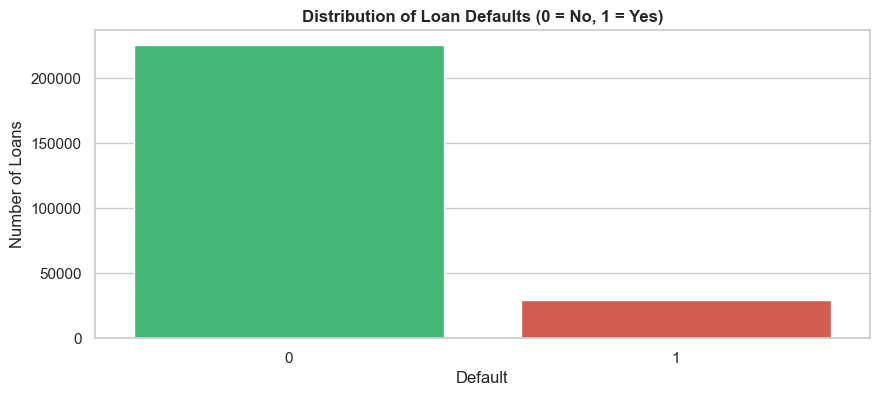

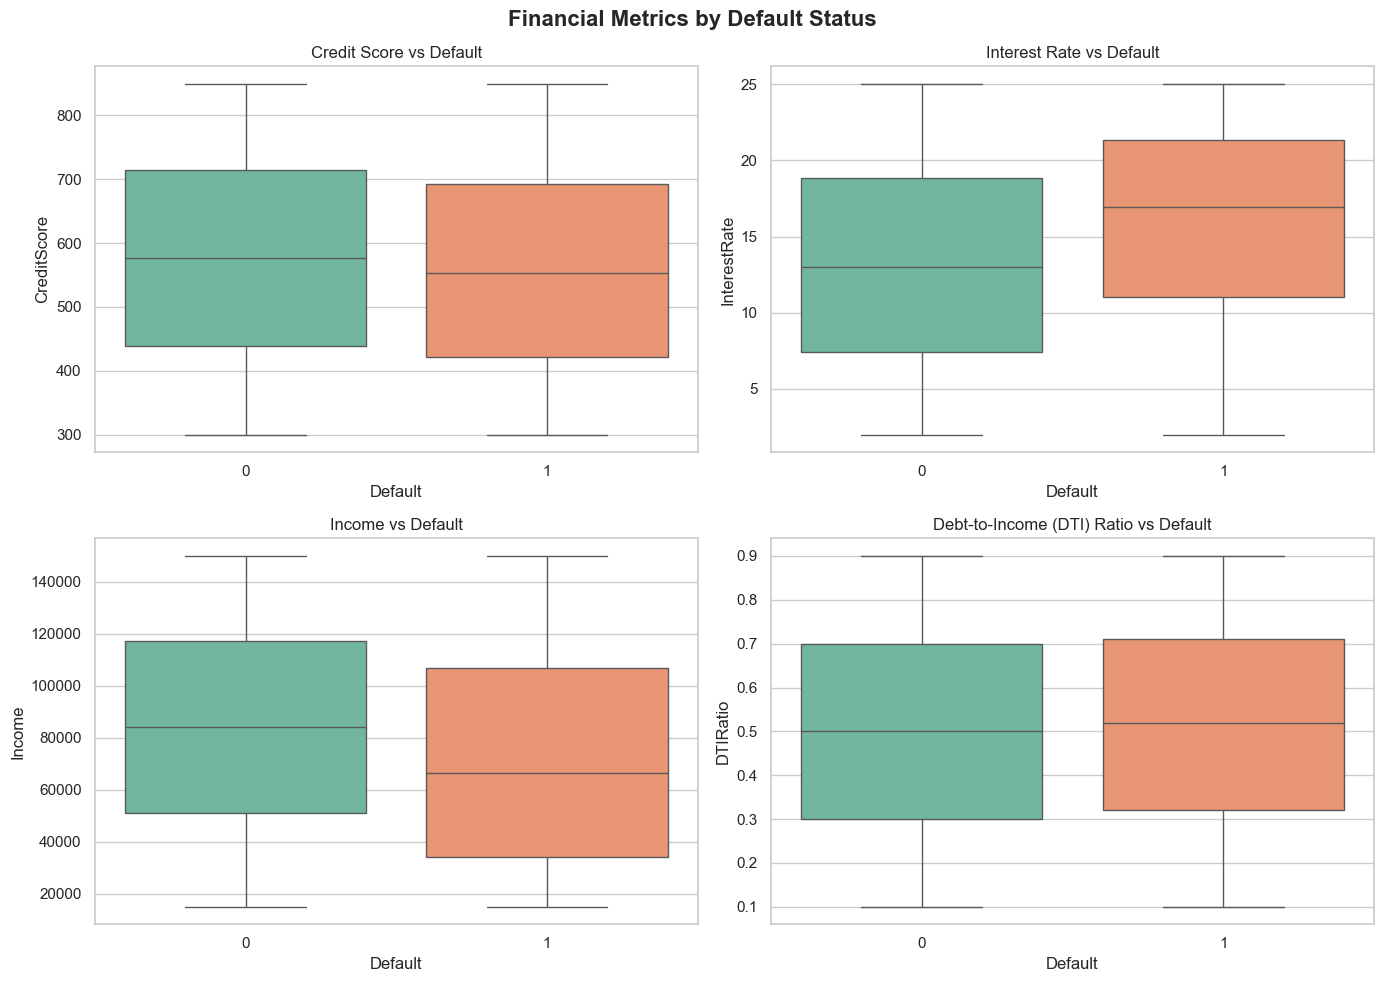

In [10]:
sns.set_theme(style="whitegrid")

# --- Plot 1: Target Variable Distribution ---
plt.figure(figsize=(10, 4))
sns.countplot(data=dataset, x='Default', palette=['#2ecc71', '#e74c3c'])
plt.title('Distribution of Loan Defaults (0 = No, 1 = Yes)', weight='bold')
plt.ylabel('Number of Loans')
plt.show()

# --- Plot 2: Key Financial Metrics vs Default (Boxplots) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Financial Metrics by Default Status', fontsize=16, weight='bold')

sns.boxplot(ax=axes[0, 0], data=dataset, x='Default', y='CreditScore', palette='Set2')
axes[0, 0].set_title('Credit Score vs Default')

sns.boxplot(ax=axes[0, 1], data=dataset, x='Default', y='InterestRate', palette='Set2')
axes[0, 1].set_title('Interest Rate vs Default')

sns.boxplot(ax=axes[1, 0], data=dataset, x='Default', y='Income', palette='Set2')
axes[1, 0].set_title('Income vs Default')

sns.boxplot(ax=axes[1, 1], data=dataset, x='Default', y='DTIRatio', palette='Set2')
axes[1, 1].set_title('Debt-to-Income (DTI) Ratio vs Default')

plt.tight_layout()
plt.show()


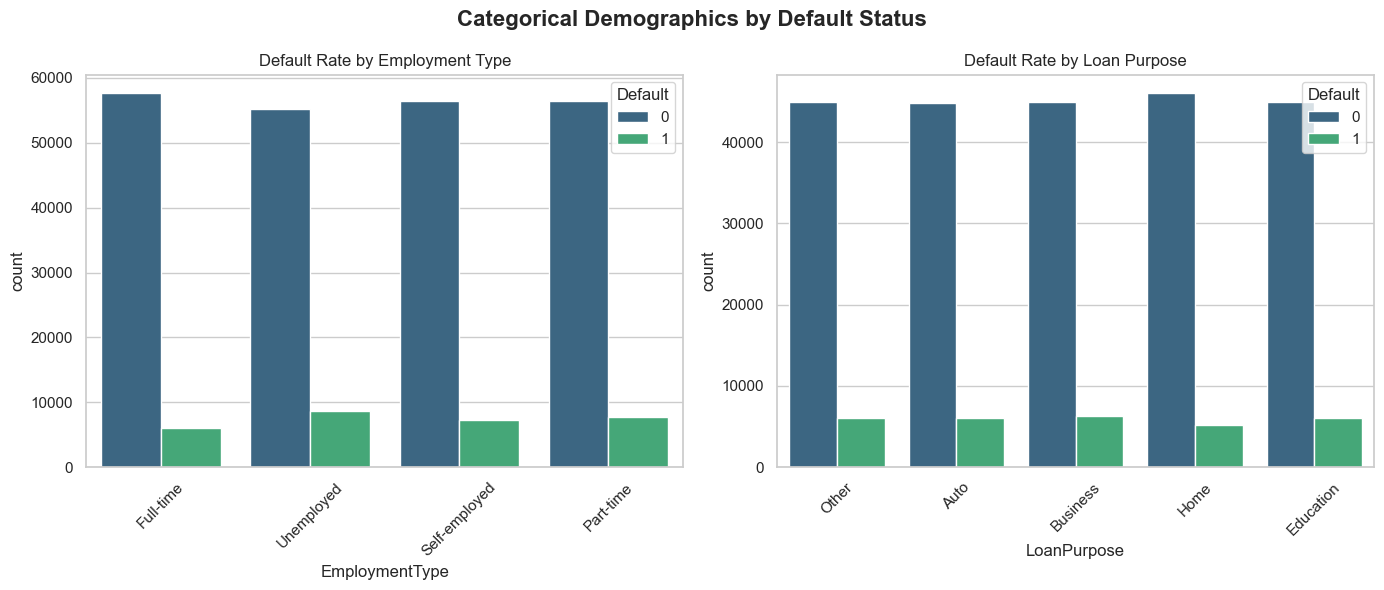

In [11]:
# --- Plot 3: Categorical Features vs Default (Stacked/Grouped Bar Charts) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Categorical Demographics by Default Status', fontsize=16, weight='bold')

# Employment Type vs Default
sns.countplot(ax=axes[0], data=dataset, x='EmploymentType', hue='Default', palette='viridis')
axes[0].set_title('Default Rate by Employment Type')
axes[0].tick_params(axis='x', rotation=45)

# Loan Purpose vs Default
sns.countplot(ax=axes[1], data=dataset, x='LoanPurpose', hue='Default', palette='viridis')
axes[1].set_title('Default Rate by Loan Purpose')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

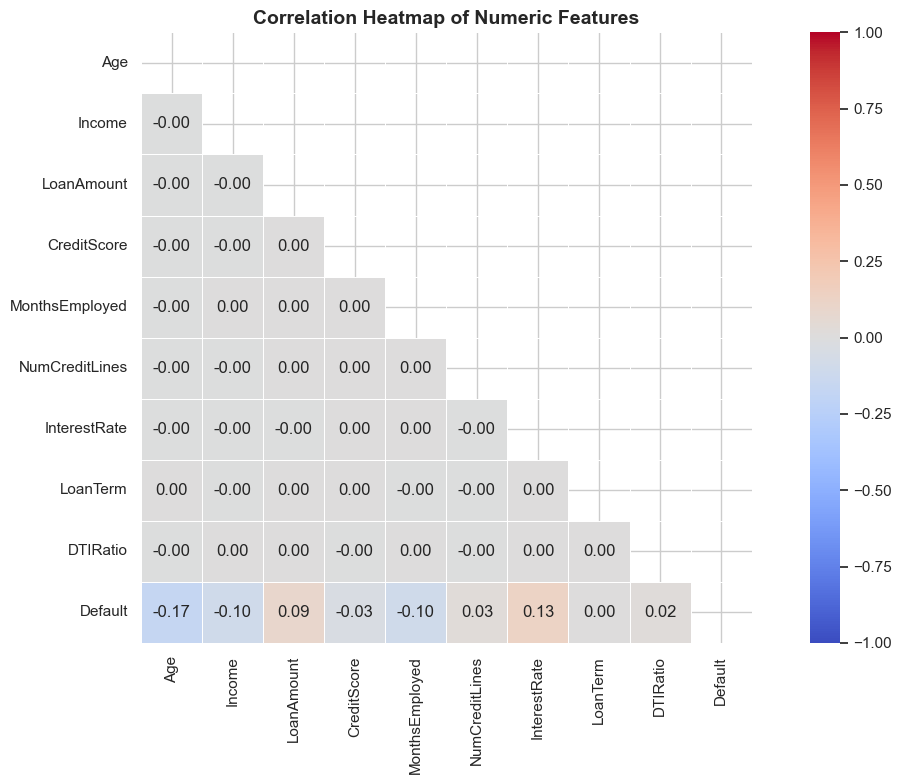

In [14]:
# --- Plot 4: Correlation Heatmap (Numeric Variables Only) ---
plt.figure(figsize=(12, 8))
# Select only numeric columns to avoid correlation errors
numeric_cols = dataset.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()

# Mask the upper triangle for cleaner visualization
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmax=1, vmin=-1, center=0, square=True, linewidths=.5)
plt.title('Correlation Heatmap of Numeric Features', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

## Model Creation

In [17]:
X = dataset.drop('Default', axis=1)
y = dataset['Default']

In [18]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
# 3. Categorize your specific columns
numeric_features = [
    'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 
    'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio'
]

categorical_features = [
    'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 
    'HasDependents', 'LoanPurpose', 'HasCoSigner'
]

##  Build Preprocessing Pipelines

In [23]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])




## Create the distinct model pipelines

In [24]:

log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42, max_depth=3))
])

## Model Creation

In [26]:
# 5. Train both pipelines
log_reg_pipeline.fit(X_train, y_train)
print("--- Logistic Regression ---")
log_preds = log_reg_pipeline.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, log_preds):.2f}")

--- Logistic Regression ---
Accuracy: 0.89


In [37]:
log=confusion_matrix(y_test,log_preds)

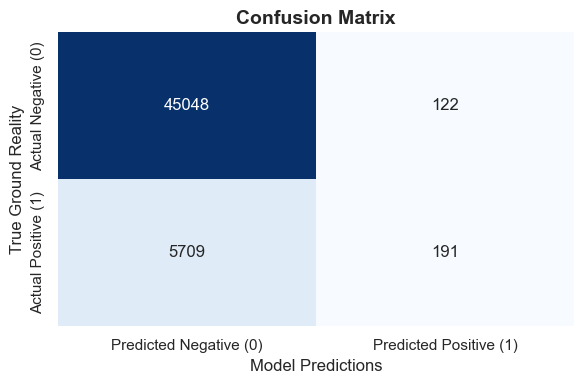

In [38]:
plt.figure(figsize=(6, 4))
sns.heatmap(log, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
            yticklabels=['Actual Negative (0)', 'Actual Positive (1)'])

# Add labels and title
plt.title('Confusion Matrix', fontsize=14, weight='bold')
plt.xlabel('Model Predictions', fontsize=12)
plt.ylabel('True Ground Reality', fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()

In [27]:
tree_pipeline.fit(X_train, y_train)
print("\n--- Decision Tree Classifier ---")
tree_preds = tree_pipeline.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, tree_preds):.2f}")


--- Decision Tree Classifier ---
Accuracy: 0.88


In [35]:
tree=confusion_matrix(y_test,tree_preds)

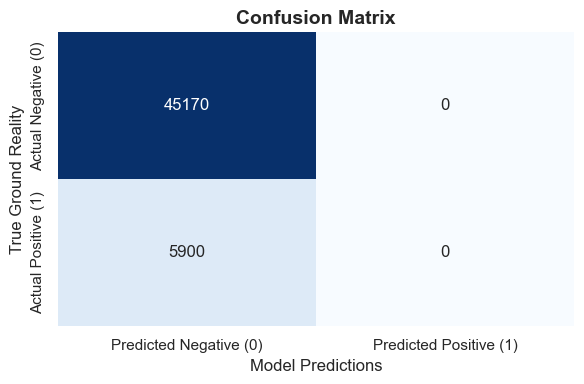

In [36]:
plt.figure(figsize=(6, 4))
sns.heatmap(tree, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
            yticklabels=['Actual Negative (0)', 'Actual Positive (1)'])

# Add labels and title
plt.title('Confusion Matrix', fontsize=14, weight='bold')
plt.xlabel('Model Predictions', fontsize=12)
plt.ylabel('True Ground Reality', fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()